### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import contractions
import spacy
import shap
import joblib
import json
from textblob import TextBlob
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV

c:\Users\himan\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Dataset Loading

In [2]:
# Load Dataset
dataset = pd.read_csv('Customer_support_data.csv')

In [3]:
# Dataset First Look
dataset.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01-08-2023 11:13,01-08-2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01-08-2023 12:52,01-08-2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01-08-2023 20:16,01-08-2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01-08-2023 20:56,01-08-2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01-08-2023 10:30,01-08-2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [4]:
# Dataset Rows & Columns count
print(f'Rows: {len(dataset)}\nColumn: {len(dataset.columns)}')

Rows: 85907
Column: 20


In [5]:
# Dataset Info
dataset.shape

(85907, 20)

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
duplicates = dataset.duplicated().sum()
print(f'Number of duplicate Rows: {duplicates}')

Number of duplicate Rows: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
dtype = dataset.dtypes
missing_count = dataset.isnull().sum()
missing_percentage = (missing_count/len(dataset))*100
missing_df = pd.DataFrame({
    'Missing Count': missing_count, 
    'Missing %': missing_percentage,
    'Datatype': dtype
    })
missing_df = missing_df[missing_df['Missing %']>0].sort_values(by='Missing %', ascending=False)
missing_df

,Missing Count,Missing %,Datatype
connected_handling_time,85665,99.718300,float64
Customer_City,68828,80.119199,object
Product_category,68711,79.983005,object
Item_price,68701,79.971364,float64
order_date_time,68693,79.962052,object
Customer Remarks,57165,66.542889,object
Order_id,18232,21.222950,object


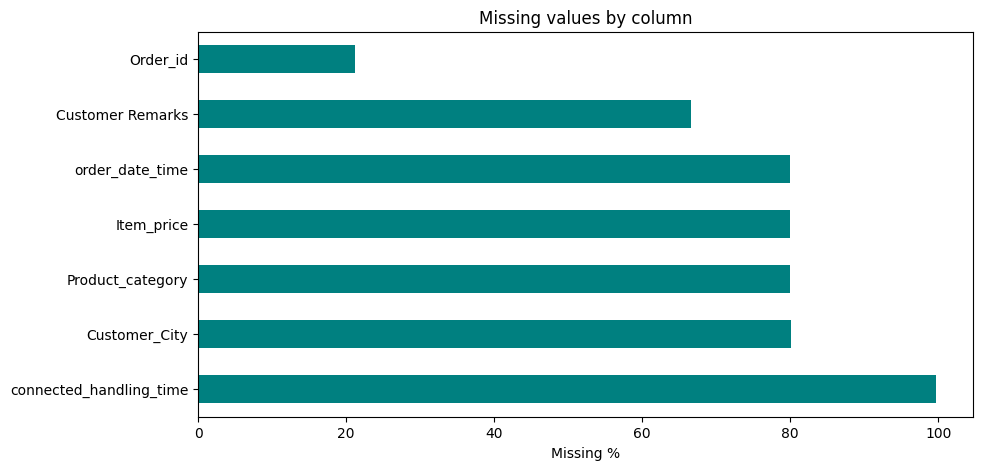

In [8]:
# Visualizing the missing values
# Barplot of missing %
missing_df['Missing %'].plot(kind='barh', figsize=(10,5), color='teal')
plt.xlabel('Missing %')
plt.title('Missing values by column')
plt.show()


In [9]:
# Dataset Columns
dataset.columns.tolist()

['Unique id',
 'channel_name',
 'category',
 'Sub-category',
 'Customer Remarks',
 'Order_id',
 'order_date_time',
 'Issue_reported at',
 'issue_responded',
 'Survey_response_Date',
 'Customer_City',
 'Product_category',
 'Item_price',
 'connected_handling_time',
 'Agent_name',
 'Supervisor',
 'Manager',
 'Tenure Bucket',
 'Agent Shift',
 'CSAT Score']

In [10]:
# Dataset Describe
dataset.describe

<bound method NDFrame.describe of                                   Unique id channel_name         category  \
0      7e9ae164-6a8b-4521-a2d4-58f7c9fff13f      Outcall  Product Queries   
1      b07ec1b0-f376-43b6-86df-ec03da3b2e16      Outcall  Product Queries   
2      200814dd-27c7-4149-ba2b-bd3af3092880      Inbound    Order Related   
3      eb0d3e53-c1ca-42d3-8486-e42c8d622135      Inbound          Returns   
4      ba903143-1e54-406c-b969-46c52f92e5df      Inbound     Cancellation   
...                                     ...          ...              ...   
85902  505ea5e7-c475-4fac-ac36-1d19a4cb610f      Inbound   Refund Related   
85903  44b38d3f-1523-4182-aba2-72917586647c      Inbound    Order Related   
85904  723bce2c-496c-4aa8-a64b-ca17004528f0      Inbound    Order Related   
85905  707528ee-6873-4192-bfa9-a491f1c08ab5      Inbound         Feedback   
85906  07c7a878-0d5a-42e0-97ef-de59abec0238      Inbound          Returns   

                       Sub-category      

In [11]:
# Check Unique Values for each variable.
unique_counts = dataset.nunique().sort_values(ascending=False)
print(unique_counts)

Unique id                  85907
Order_id                   67675
Issue_reported at          30923
issue_responded            30262
Customer Remarks           18231
order_date_time            13766
Item_price                  2789
Customer_City               1782
Agent_name                  1371
connected_handling_time      211
Sub-category                  57
Supervisor                    40
Survey_response_Date          31
category                      12
Product_category               9
Manager                        6
Agent Shift                    5
Tenure Bucket                  5
CSAT Score                     5
channel_name                   3
dtype: int64


In [ ]:
num_duplicates = dataset.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")
if num_duplicates > 0:
    dataset.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape: {dataset.shape}")


dataset.columns = dataset.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')
print("\nFixed column names:")
print(dataset.columns.tolist())


date_columns = ['order_date_time', 'issue_reported_at', 'issue_responded', 'survey_response_date']
for col in date_columns:
    dataset[col] = pd.to_datetime(dataset[col], dayfirst=True, errors='coerce')
print("\nConverted date columns to datetime:")
print(dataset[date_columns].dtypes)



dataset['response_delay_minutes'] = (
    (dataset['issue_responded'] - dataset['issue_reported_at']).dt.total_seconds() / 60
)


dataset['order_dayofweek'] = dataset['order_date_time'].dt.dayofweek
print("\nAdded helper columns: 'response_delay_minutes' and 'order_dayofweek'")


columns_to_drop = ['supervisor', 'manager', 'unique_id']
dataset.drop(columns=columns_to_drop, inplace=True, errors='ignore')
print(f"\nDropped columns: {columns_to_drop}")
print(f"Current shape: {dataset.shape}")


missing_percent = dataset.isnull().mean() * 100
high_missing = missing_percent[missing_percent > 50].sort_values(ascending=False)
print("\nColumns with >50% missing values:")
print(high_missing)


dataset.reset_index(drop=True, inplace=True)
print("\nFinal dataset shape after wrangling:", dataset.shape)


Number of duplicate rows: 0

Fixed column names:
['unique_id', 'channel_name', 'category', 'sub_category', 'customer_remarks', 'order_id', 'order_date_time', 'issue_reported_at', 'issue_responded', 'survey_response_date', 'customer_city', 'product_category', 'item_price', 'connected_handling_time', 'agent_name', 'supervisor', 'manager', 'tenure_bucket', 'agent_shift', 'csat_score']

Converted date columns to datetime:
order_date_time         datetime64[ns]
issue_reported_at       datetime64[ns]
issue_responded         datetime64[ns]
survey_response_date    datetime64[ns]
dtype: object

Added helper columns: 'response_delay_minutes' and 'order_dayofweek'

Dropped columns: ['supervisor', 'manager', 'unique_id']
Current shape: (85907, 19)

Columns with >50% missing values:
connected_handling_time    99.718300
customer_city              80.119199
product_category           79.983005
item_price                 79.971364
order_date_time            79.962052
order_dayofweek            79.9620

C:\Users\himan\AppData\Local\Temp\ipykernel_4276\1006387536.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset[col] = pd.to_datetime(dataset[col], dayfirst=True, errors='coerce')


### **Univariate Graphs**

#### Chart - 1

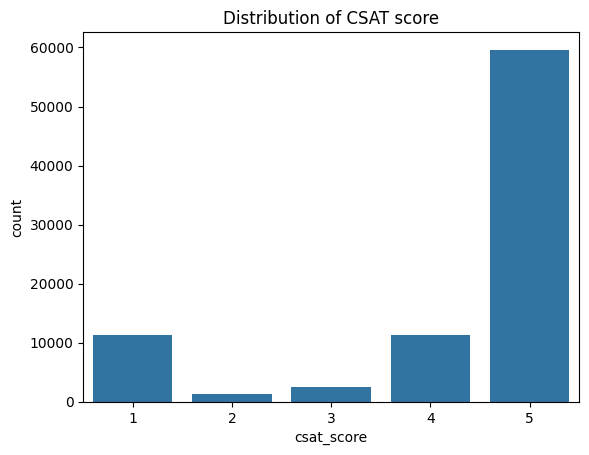

In [13]:
# Chart - 1 visualization code
sns.countplot(x='csat_score',data=dataset)
plt.title('Distribution of CSAT score')
plt.show()

#### Chart - 2

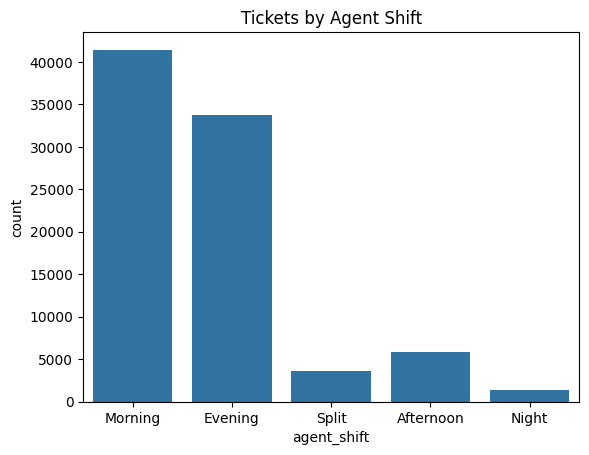

In [14]:
# Chart - 2 visualization code
sns.countplot(x='agent_shift', data=dataset)
plt.title('Tickets by Agent Shift')
plt.show()

#### Chart - 3

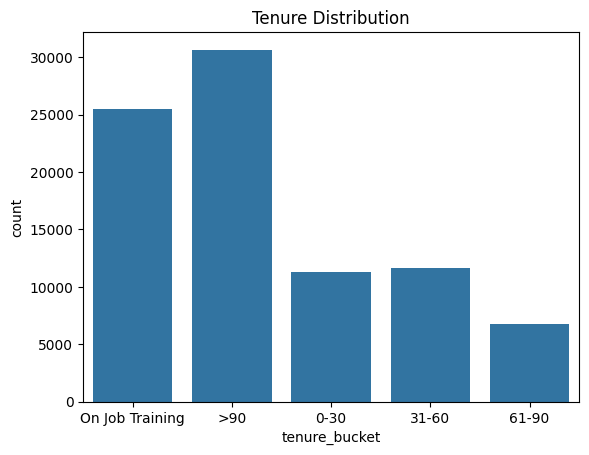

In [15]:
# Chart - 3 visualization code
sns.countplot(x='tenure_bucket', data=dataset)
plt.title('Tenure Distribution')
plt.show()

#### Chart - 4

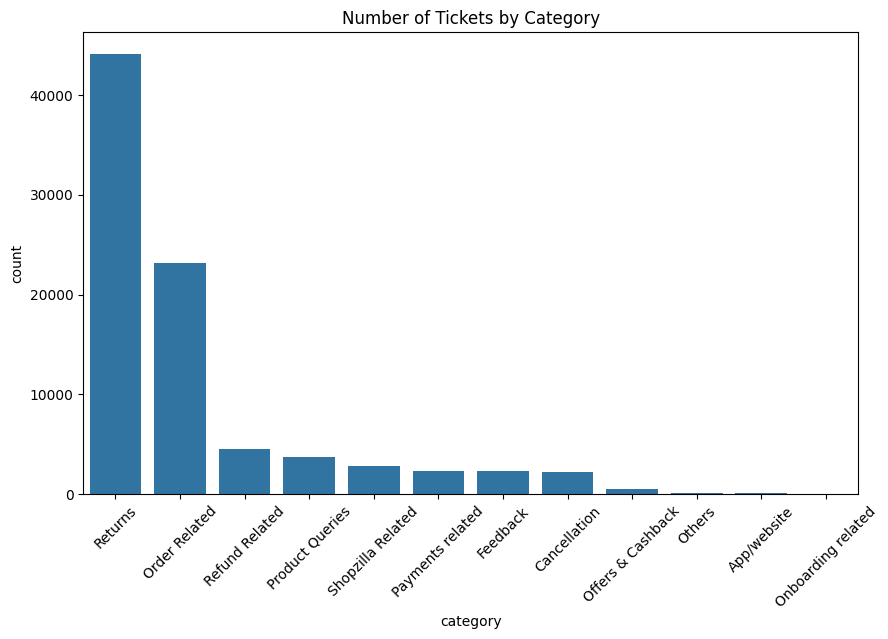

In [16]:
# Chart - 4 visualization code
plt.figure(figsize=(10,6))
sns.countplot(x='category', data=dataset, order=dataset['category'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Number of Tickets by Category')
plt.show()

#### Chart - 5

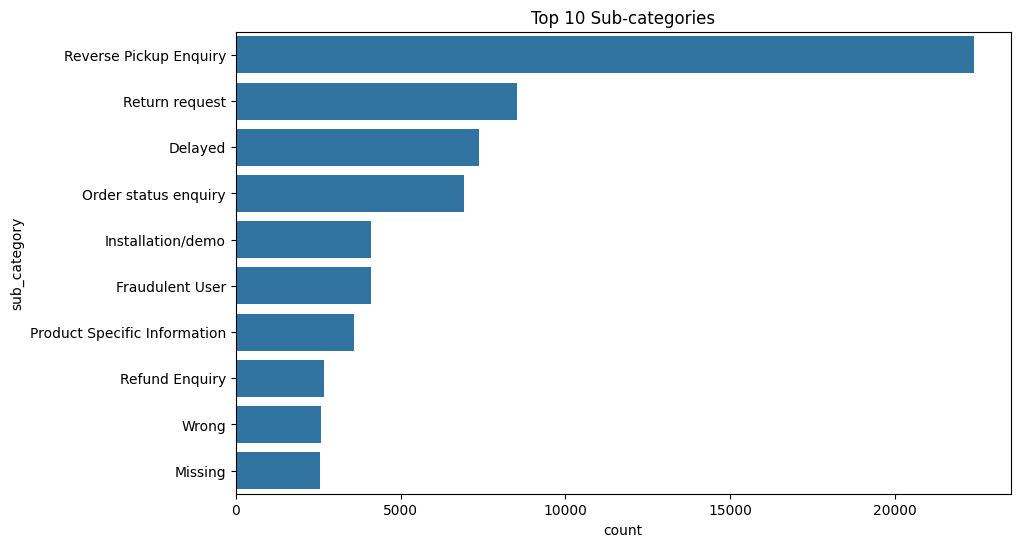

In [17]:
# Chart - 5 visualization code
top_subcats = dataset['sub_category'].value_counts().nlargest(10).index
top_subcats_dataset = dataset[dataset['sub_category'].isin(top_subcats)]
plt.figure(figsize=(10,6))
sns.countplot(y='sub_category', data=top_subcats_dataset,order=top_subcats)
plt.title('Top 10 Sub-categories')
plt.show()


#### Chart - 6

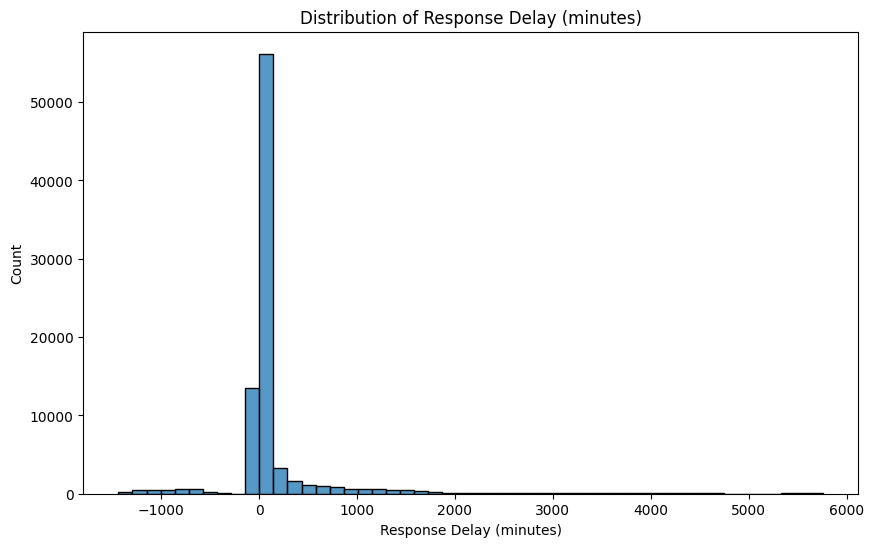

In [18]:
# Chart - 6 visualization code
plt.figure(figsize=(10,6))
sns.histplot(dataset['response_delay_minutes'].dropna(), bins=50)
plt.title('Distribution of Response Delay (minutes)')
plt.xlabel('Response Delay (minutes)')
plt.show()

#### Chart - 7

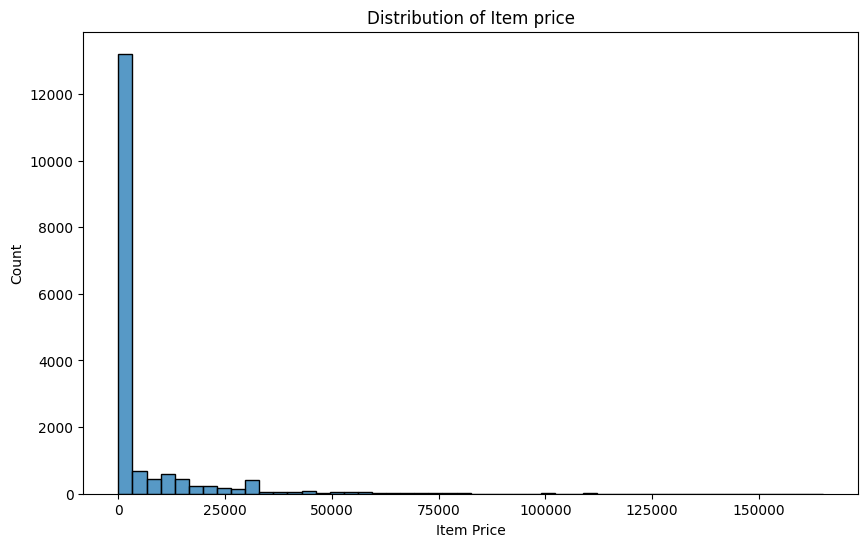

In [19]:
# Chart - 7 visualization code
plt.figure(figsize=(10,6))
sns.histplot(dataset['item_price'].dropna(), bins=50)
plt.title('Distribution of Item price')
plt.xlabel('Item Price')
plt.show()

### **Bivariate Graphs**

#### Chart - 8

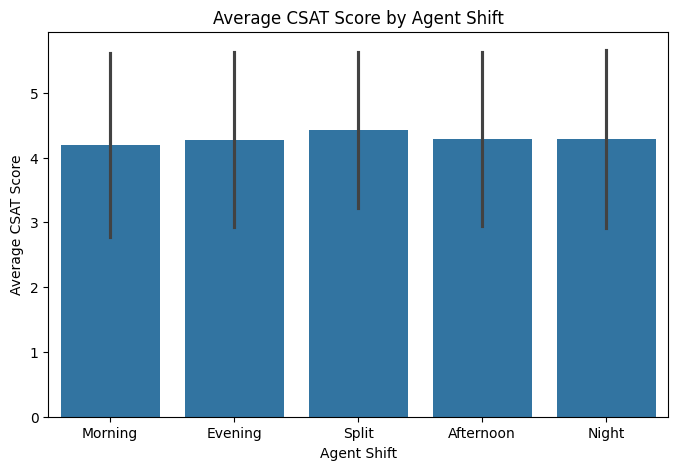

In [20]:
# Chart - 8 visualization code
plt.figure(figsize=(8,5))
sns.barplot(x='agent_shift', y='csat_score', data=dataset, estimator=np.mean, errorbar='sd')
plt.title("Average CSAT Score by Agent Shift")
plt.xlabel("Agent Shift")
plt.ylabel("Average CSAT Score")
plt.show()


#### Chart - 9

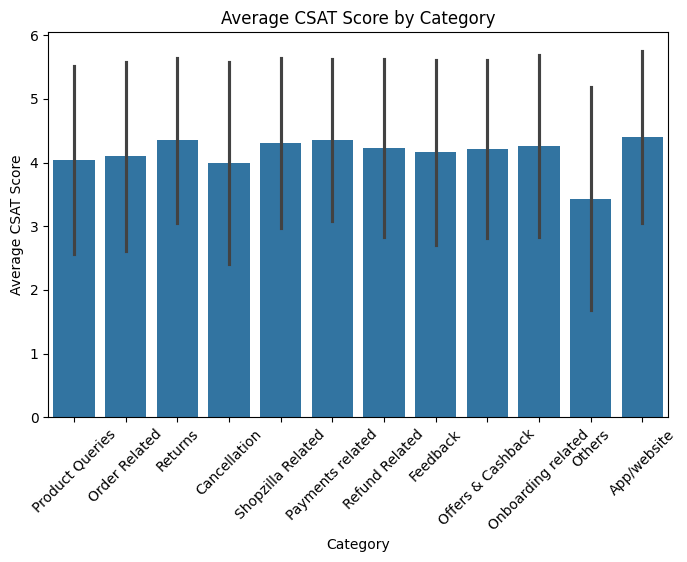

In [21]:
# Chart - 9 visualization code
plt.figure(figsize=(8,5))
sns.barplot(x='category', y='csat_score', data=dataset, estimator=np.mean, errorbar='sd')
plt.xticks(rotation=45)
plt.title("Average CSAT Score by Category")
plt.xlabel("Category")
plt.ylabel("Average CSAT Score")
plt.show()

#### Chart - 10

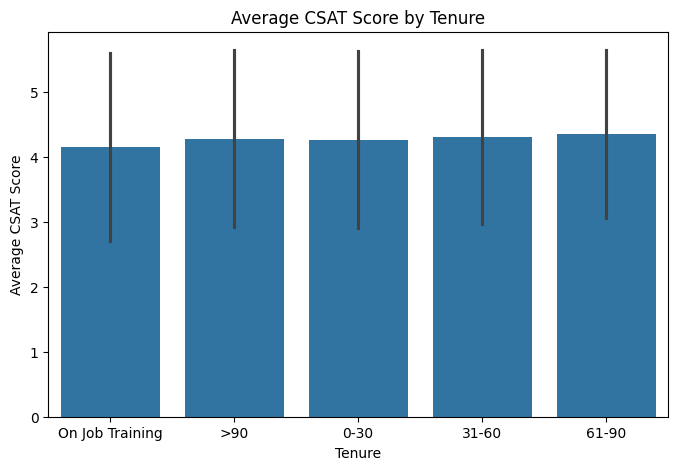

In [22]:
# Chart - 10 visualization code
plt.figure(figsize=(8,5))
sns.barplot(x='tenure_bucket', y='csat_score', data=dataset, estimator=np.mean, errorbar='sd')
plt.title("Average CSAT Score by Tenure")
plt.xlabel("Tenure")
plt.ylabel("Average CSAT Score")
plt.show()

#### Chart - 11

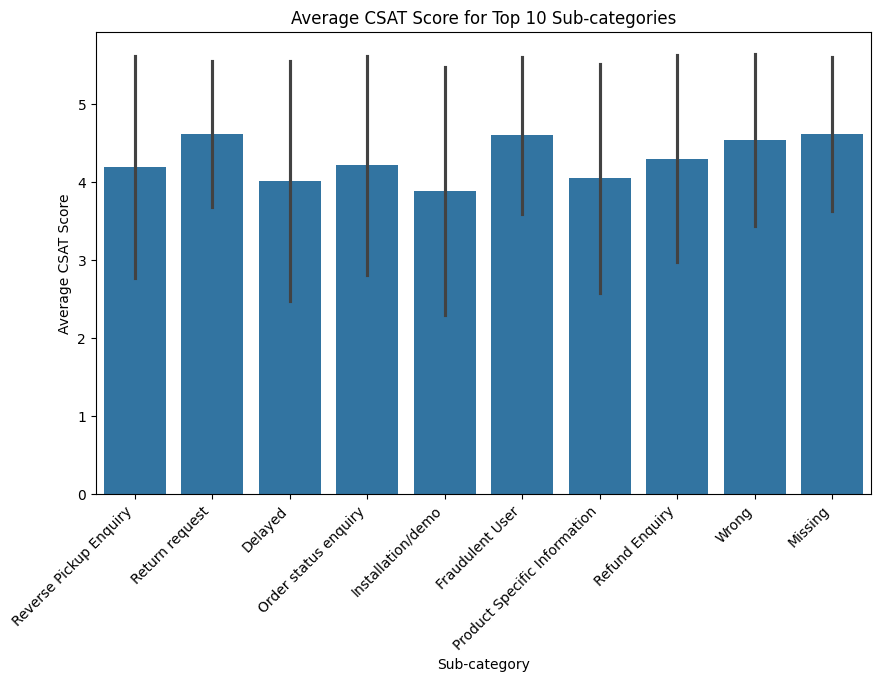

In [23]:
# Chart - 11 visualization code
plt.figure(figsize=(10,6))
sns.barplot(x='sub_category',y='csat_score',data=top_subcats_dataset,estimator=np.mean,errorbar='sd',order=top_subcats)
plt.title('Average CSAT Score for Top 10 Sub-categories')
plt.xlabel('Sub-category')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=45, ha='right')
plt.show()

### **Multivariate Graph**

#### Chart - 12

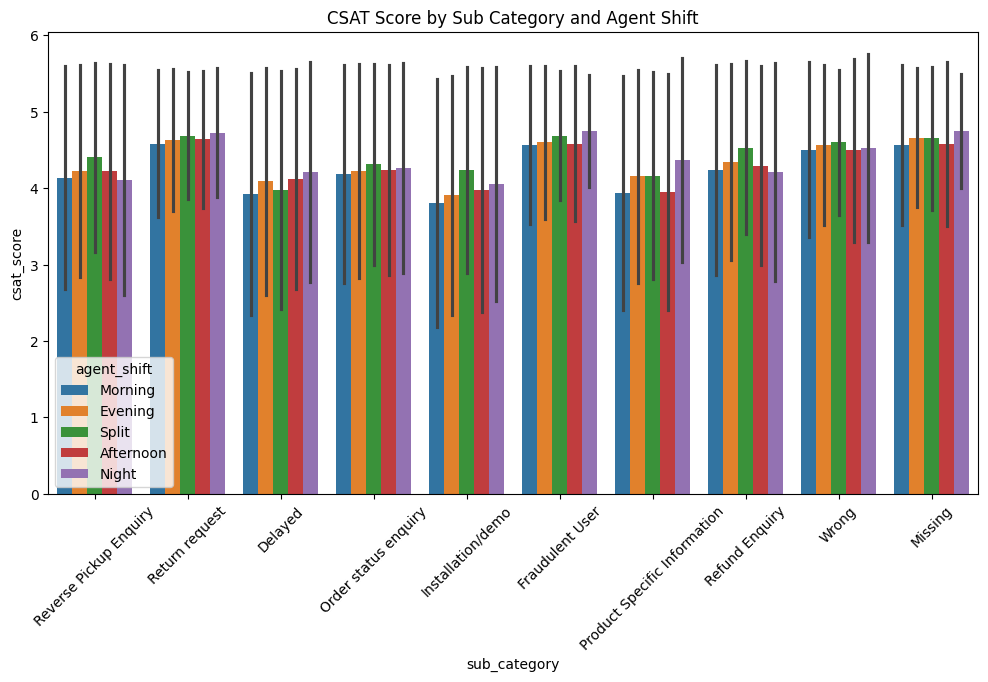

In [24]:
plt.figure(figsize=(12,6))
sns.barplot(x='sub_category', y='csat_score', hue='agent_shift',estimator=np.mean,errorbar='sd', data=top_subcats_dataset, order=top_subcats)
plt.title("CSAT Score by Sub Category and Agent Shift")
plt.xticks(rotation=45)
plt.show()

### Removing Irrelevant Columns

In [ ]:
cols_to_drop = [
    "unique_id", "order_id", "supervisor", "manager",
    "connected_handling_time", "customer_city",
    "product_category", "item_price", 'sub_category'
]
dataset.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print("Columns retained for modeling and dashboard explanation:")
print(dataset.columns.tolist())

missing_counts = dataset.isnull().sum()
print("\nMissing values in retained columns:")
print(missing_counts[missing_counts > 0].sort_values(ascending=False))


Columns retained for modeling and dashboard explanation:
['channel_name', 'category', 'customer_remarks', 'order_date_time', 'issue_reported_at', 'issue_responded', 'survey_response_date', 'agent_name', 'tenure_bucket', 'agent_shift', 'csat_score', 'response_delay_minutes', 'order_dayofweek']

Missing values in retained columns:
order_date_time     68693
order_dayofweek     68693
customer_remarks    57165
dtype: int64


In [26]:
dataset.head()

,channel_name,category,customer_remarks,order_date_time,issue_reported_at,issue_responded,survey_response_date,agent_name,tenure_bucket,agent_shift,csat_score,response_delay_minutes,order_dayofweek
0,Outcall,Product Queries,NaN,NaT,2023-08-01 11:13:00,2023-08-01 11:47:00,2023-08-01,Richard Buchanan,On Job Training,Morning,5,34.0,NaN
1,Outcall,Product Queries,NaN,NaT,2023-08-01 12:52:00,2023-08-01 12:54:00,2023-08-01,Vicki Collins,>90,Morning,5,2.0,NaN
2,Inbound,Order Related,NaN,NaT,2023-08-01 20:16:00,2023-08-01 20:38:00,2023-08-01,Duane Norman,On Job Training,Evening,5,22.0,NaN
3,Inbound,Returns,NaN,NaT,2023-08-01 20:56:00,2023-08-01 21:16:00,2023-08-01,Patrick Flores,>90,Evening,5,20.0,NaN
4,Inbound,Cancellation,NaN,NaT,2023-08-01 10:30:00,2023-08-01 10:32:00,2023-08-01,Christopher Sanchez,0-30,Morning,5,2.0,NaN


### Handling Missing Values

In [ ]:
dataset['customer_remarks'] = dataset['customer_remarks'].fillna("No Comments")

missing_counts = dataset.isnull().sum()
print(missing_counts[missing_counts > 0])

order_date_time    68693
order_dayofweek    68693
dtype: int64


In [ ]:
dataset['order_date_time_missing'] = dataset['order_date_time'].isnull().astype(int)  


placeholder_date = pd.Timestamp('1900-01-01')
dataset['order_date_time'] = dataset['order_date_time'].fillna(placeholder_date)


dataset['order_date_time_ts'] = dataset['order_date_time'].astype('int64')


dataset['order_dayofweek'] = dataset['order_date_time'].dt.dayofweek  
dataset['order_month'] = dataset['order_date_time'].dt.month          
dataset['order_hour'] = dataset['order_date_time'].dt.hour            


print("Missing values after datetime imputation:")
print(dataset[['order_date_time', 'order_date_time_missing']].isnull().sum())


Missing values after datetime imputation:
order_date_time            0
order_date_time_missing    0
dtype: int64


### Checking for Outliers

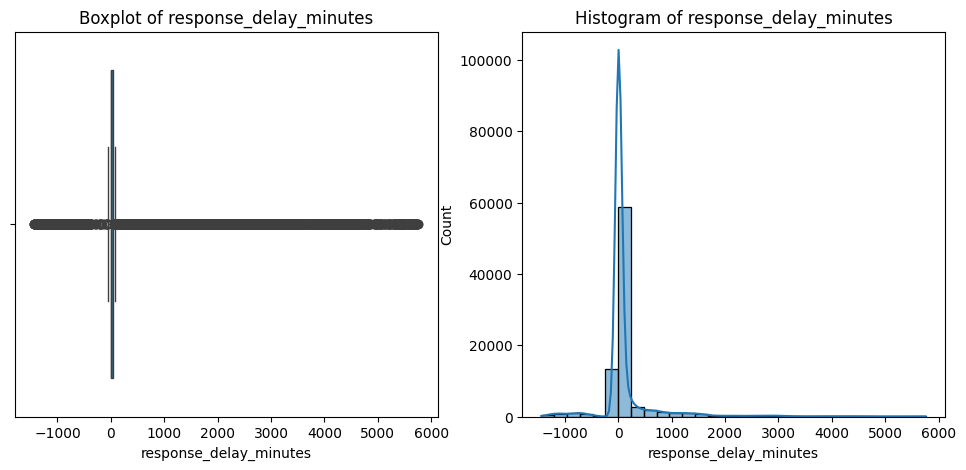

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

columns_to_check = ['response_delay_minutes']

for col in columns_to_check:
    plt.figure(figsize=(12,5))
    
    plt.subplot(1, 2, 1)
    sns.boxplot(x=dataset[col])
    plt.title(f'Boxplot of {col}')
    
    plt.subplot(1, 2, 2)
    sns.histplot(dataset[col], bins=30, kde=True)
    plt.title(f'Histogram of {col}')
    
    plt.show()


### Handling Outliers

In [ ]:
dataset['response_delay_minutes'] = dataset['response_delay_minutes'].apply(lambda x: max(x, 0))

Q1 = dataset['response_delay_minutes'].quantile(0.25)
Q3 = dataset['response_delay_minutes'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

dataset['response_delay_minutes'] = dataset['response_delay_minutes'].apply(lambda x: min(x, upper_bound))
dataset['response_delay_minutes']

0        34.0
1         2.0
2        22.0
3        20.0
4         2.0
         ... 
85902    84.5
85903     2.0
85904     5.0
85905     1.0
85906     1.0
Name: response_delay_minutes, Length: 85907, dtype: float64

### Categorical Encoding

In [31]:
one_hot_cols = [
    'channel_name', 'category', 'agent_shift', 'tenure_bucket'
]
dataset = pd.get_dummies(dataset, columns=one_hot_cols,drop_first=True)

agent_freq = dataset['agent_name'].value_counts().to_dict()
dataset['agent_name_encoded'] = dataset['agent_name'].map(agent_freq)


dataset.head()

,customer_remarks,order_date_time,issue_reported_at,issue_responded,survey_response_date,agent_name,csat_score,response_delay_minutes,order_dayofweek,order_date_time_missing,...,category_Shopzilla Related,agent_shift_Evening,agent_shift_Morning,agent_shift_Night,agent_shift_Split,tenure_bucket_31-60,tenure_bucket_61-90,tenure_bucket_>90,tenure_bucket_On Job Training,agent_name_encoded
0,No Comments,1900-01-01,2023-08-01 11:13:00,2023-08-01 11:47:00,2023-08-01,Richard Buchanan,5,34.0,0,1,...,False,False,True,False,False,False,False,False,True,42
1,No Comments,1900-01-01,2023-08-01 12:52:00,2023-08-01 12:54:00,2023-08-01,Vicki Collins,5,2.0,0,1,...,False,False,True,False,False,False,False,True,False,32
2,No Comments,1900-01-01,2023-08-01 20:16:00,2023-08-01 20:38:00,2023-08-01,Duane Norman,5,22.0,0,1,...,False,True,False,False,False,False,False,False,True,35
3,No Comments,1900-01-01,2023-08-01 20:56:00,2023-08-01 21:16:00,2023-08-01,Patrick Flores,5,20.0,0,1,...,False,True,False,False,False,False,False,True,False,48
4,No Comments,1900-01-01,2023-08-01 10:30:00,2023-08-01 10:32:00,2023-08-01,Christopher Sanchez,5,2.0,0,1,...,False,False,True,False,False,False,False,False,False,124


In [ ]:
def expand(text):
    return contractions.fix(text)

dataset['customer_remarks'] = dataset['customer_remarks'].apply(expand)
dataset.head()

,customer_remarks,order_date_time,issue_reported_at,issue_responded,survey_response_date,agent_name,csat_score,response_delay_minutes,order_dayofweek,order_date_time_missing,...,category_Shopzilla Related,agent_shift_Evening,agent_shift_Morning,agent_shift_Night,agent_shift_Split,tenure_bucket_31-60,tenure_bucket_61-90,tenure_bucket_>90,tenure_bucket_On Job Training,agent_name_encoded
0,No Comments,1900-01-01,2023-08-01 11:13:00,2023-08-01 11:47:00,2023-08-01,Richard Buchanan,5,34.0,0,1,...,False,False,True,False,False,False,False,False,True,42
1,No Comments,1900-01-01,2023-08-01 12:52:00,2023-08-01 12:54:00,2023-08-01,Vicki Collins,5,2.0,0,1,...,False,False,True,False,False,False,False,True,False,32
2,No Comments,1900-01-01,2023-08-01 20:16:00,2023-08-01 20:38:00,2023-08-01,Duane Norman,5,22.0,0,1,...,False,True,False,False,False,False,False,False,True,35
3,No Comments,1900-01-01,2023-08-01 20:56:00,2023-08-01 21:16:00,2023-08-01,Patrick Flores,5,20.0,0,1,...,False,True,False,False,False,False,False,True,False,48
4,No Comments,1900-01-01,2023-08-01 10:30:00,2023-08-01 10:32:00,2023-08-01,Christopher Sanchez,5,2.0,0,1,...,False,False,True,False,False,False,False,False,False,124


In [ ]:
def lowercase(text):
    return text.lower()

dataset['customer_remarks'] = dataset['customer_remarks'].apply(lowercase)

In [ ]:
exclude = string.punctuation
def remove_punctuation(text):
    for word in exclude:
        text = text.replace(word, ' ')
    return text

dataset['customer_remarks'] = dataset['customer_remarks'].apply(remove_punctuation)

In [ ]:
def remove_urls_and_digits(text):
    text = re.sub(r'https\S+|http\S+|www\S+', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

dataset['customer_remarks'] = dataset['customer_remarks'].apply(remove_urls_and_digits)

In [ ]:
nlp = spacy.load('en_core_web_sm')

def preprocess_text_spacy(text):
    doc = nlp(text.strip())
    
    tokens = []
    pos_tags = []
    
    for token in doc:
        if not token.is_stop and not token.is_punct and not token.is_space:
            lemma = token.lemma_
            tokens.append(lemma)
            pos_tags.append((lemma, token.pos_))
    
    return tokens, pos_tags

dataset[['customer_remarks_tokens', 'customer_remarks_pos']] = dataset['customer_remarks'].fillna('').apply(
    lambda x: pd.Series(preprocess_text_spacy(x))
)

print(dataset[['customer_remarks_tokens', 'customer_remarks_pos']].head())

  customer_remarks_tokens customer_remarks_pos
0               [comment]    [(comment, NOUN)]
1               [comment]    [(comment, NOUN)]
2               [comment]    [(comment, NOUN)]
3               [comment]    [(comment, NOUN)]
4               [comment]    [(comment, NOUN)]


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
dataset['customer_remarks_cleaned'] = dataset['customer_remarks_tokens'].apply(lambda tokens: ' '.join(tokens))
tfidf = TfidfVectorizer()
tfidf.fit_transform(dataset['customer_remarks_cleaned'])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 164775 stored elements and shape (85907, 8067)>

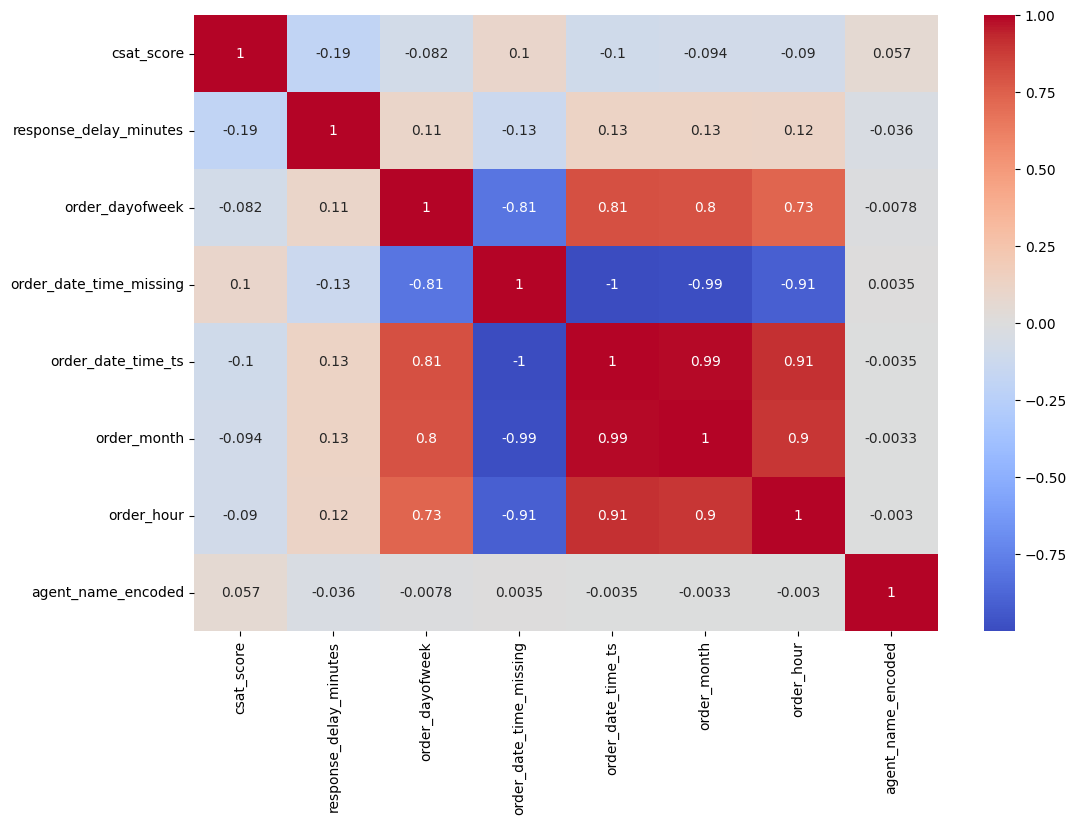

In [ ]:
numeric_cols = dataset.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [39]:
high_corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={0: 'correlation'})
)
high_corr_pairs = high_corr_pairs[abs(high_corr_pairs['correlation']) > 0.9]
print(high_corr_pairs)

                    level_0             level_1  correlation
18  order_date_time_missing  order_date_time_ts    -0.999999
19  order_date_time_missing         order_month    -0.989470
20  order_date_time_missing          order_hour    -0.906842
22       order_date_time_ts         order_month     0.989525
23       order_date_time_ts          order_hour     0.906846


In [40]:
dataset.drop(['order_date_time_missing', 'order_date_time_ts'], axis=1, inplace=True)

In [ ]:
dataset['hour'] = dataset['issue_reported_at'].dt.hour

dataset['part_of_day'] = pd.cut(
    dataset['hour'],
    bins=[-1, 6, 12, 18, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening']
)

dataset['is_weekend'] = dataset['order_dayofweek'].isin([5, 6]).astype(int)

dataset['response_speed'] = pd.cut(
    dataset['response_delay_minutes'],
    bins=[-1, 5, 30, 9999],
    labels=['Fast', 'Average', 'Slow']
)

dataset['remark_length'] = dataset['customer_remarks'].apply(lambda x: len(str(x)))

dataset['num_tokens'] = dataset['customer_remarks_tokens'].apply(len)

dataset['sentiment'] = dataset['customer_remarks'].apply(lambda x: TextBlob(x).sentiment.polarity)


dataset.drop(['hour'], axis=1, inplace=True)

dataset.head()


,customer_remarks,order_date_time,issue_reported_at,issue_responded,survey_response_date,agent_name,csat_score,response_delay_minutes,order_dayofweek,order_month,...,agent_name_encoded,customer_remarks_tokens,customer_remarks_pos,customer_remarks_cleaned,part_of_day,is_weekend,response_speed,remark_length,num_tokens,sentiment
0,no comments,1900-01-01,2023-08-01 11:13:00,2023-08-01 11:47:00,2023-08-01,Richard Buchanan,5,34.0,0,1,...,42,[comment],"[(comment, NOUN)]",comment,Morning,0,Slow,11,1,0.0
1,no comments,1900-01-01,2023-08-01 12:52:00,2023-08-01 12:54:00,2023-08-01,Vicki Collins,5,2.0,0,1,...,32,[comment],"[(comment, NOUN)]",comment,Morning,0,Fast,11,1,0.0
2,no comments,1900-01-01,2023-08-01 20:16:00,2023-08-01 20:38:00,2023-08-01,Duane Norman,5,22.0,0,1,...,35,[comment],"[(comment, NOUN)]",comment,Evening,0,Average,11,1,0.0
3,no comments,1900-01-01,2023-08-01 20:56:00,2023-08-01 21:16:00,2023-08-01,Patrick Flores,5,20.0,0,1,...,48,[comment],"[(comment, NOUN)]",comment,Evening,0,Average,11,1,0.0
4,no comments,1900-01-01,2023-08-01 10:30:00,2023-08-01 10:32:00,2023-08-01,Christopher Sanchez,5,2.0,0,1,...,124,[comment],"[(comment, NOUN)]",comment,Morning,0,Fast,11,1,0.0


In [ ]:
from sklearn.ensemble import RandomForestClassifier

target = 'csat_score'
X = dataset.drop([target], axis=1)
y = dataset[target]

X_numeric = X.select_dtypes(include=[np.number])

print("Remaining features for model:", X_numeric.columns.tolist())

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_numeric, y)

importances_df = pd.DataFrame({
    'feature': X_numeric.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

top_n = 15 
top_features = importances_df.head(top_n)
print(top_features)

selected_features = top_features['feature'].tolist()
X_selected = X[selected_features]

print("Reduced feature set shape:", X_selected.shape)

Remaining features for model: ['response_delay_minutes', 'order_dayofweek', 'order_month', 'order_hour', 'agent_name_encoded', 'is_weekend', 'remark_length', 'num_tokens', 'sentiment']
                  feature  importance
4      agent_name_encoded    0.368654
0  response_delay_minutes    0.183993
8               sentiment    0.135004
6           remark_length    0.118122
3              order_hour    0.080518
7              num_tokens    0.050794
1         order_dayofweek    0.035966
2             order_month    0.021396
5              is_weekend    0.005553
Reduced feature set shape: (85907, 9)


In [43]:
important_features = [
    'response_delay_minutes', 'order_dayofweek', 'order_month', 'order_hour',
    'agent_name_encoded', 'is_weekend', 'remark_length', 'num_tokens', 
    'sentiment', 'csat_score'
]

dataset = dataset[important_features]

print(f"Final dataset shape after dropping irrelevant features: {dataset.shape}")
dataset.head()

Final dataset shape after dropping irrelevant features: (85907, 10)


,response_delay_minutes,order_dayofweek,order_month,order_hour,agent_name_encoded,is_weekend,remark_length,num_tokens,sentiment,csat_score
0,34.0,0,1,0,42,0,11,1,0.0,5
1,2.0,0,1,0,32,0,11,1,0.0,5
2,22.0,0,1,0,35,0,11,1,0.0,5
3,20.0,0,1,0,48,0,11,1,0.0,5
4,2.0,0,1,0,124,0,11,1,0.0,5


In [ ]:
features_to_scale = [
    'num_tokens',           
    'response_delay_minutes', 
    'agent_name_encoded',
    'remark_length',
    'sentiment'
]

sc = StandardScaler()
dataset_scaled = dataset.copy()
dataset_scaled[features_to_scale] = sc.fit_transform(dataset[features_to_scale])

In [ ]:
X = dataset_scaled.drop('csat_score', axis=1)
y = dataset_scaled['csat_score']
y_binary = (y<=2).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, stratify=y_binary, random_state=42)

print("Training set distribution:")
print(f"Risky: {y_train.sum()} ({y_train.mean():.1%})")
print(f"Safe: {(~y_train.astype(bool)).sum()} ({(~y_train.astype(bool)).mean():.1%})")

print("\nTest set distribution:")
print(f"Risky: {y_test.sum()} ({y_test.mean():.1%})")
print(f"Safe: {(~y_test.astype(bool)).sum()} ({(~y_test.astype(bool)).mean():.1%})")

Training set distribution:
Risky: 10010 (14.6%)
Safe: 58715 (85.4%)

Test set distribution:
Risky: 2503 (14.6%)
Safe: 14679 (85.4%)


In [ ]:
sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"Training set size: {len(X_train)}")
print(f"Class distribution: {Counter(y_train)}")
print(f"Risky tickets: {y_train.sum()} ({y_train.mean():.1%})")
print(f"Safe tickets: {len(y_train) - y_train.sum()} ({(1 - y_train.mean()):.1%})")

print("\nAfter SMOTE:")
print(f"Training set size: {len(X_train_smote)}")
print(f"Class distribution: {Counter(y_train_smote)}")
print(f"Risky tickets: {y_train_smote.sum()} ({y_train_smote.mean():.1%})")
print(f"Safe tickets: {len(y_train_smote) - y_train_smote.sum()} ({(1 - y_train_smote.mean()):.1%})")

Before SMOTE:
Training set size: 68725
Class distribution: Counter({0: 58715, 1: 10010})
Risky tickets: 10010 (14.6%)
Safe tickets: 58715 (85.4%)

After SMOTE:
Training set size: 117430
Class distribution: Counter({0: 58715, 1: 58715})
Risky tickets: 58715 (50.0%)
Safe tickets: 58715 (50.0%)


In [ ]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train_smote, y_train_smote)
lr_pred = lr.predict(X_test)

In [48]:
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

In [ ]:
print(f"\nLogistic Regression Results:")
print(f"Accuracy: {lr_accuracy:.3f}")
print(f"Precision: {lr_precision:.3f}")
print(f"Recall: {lr_recall:.3f}")
print(f"F1-Score: {lr_f1:.3f}")


Logistic Regression Results:
Accuracy: 0.731
Precision: 0.295
Recall: 0.610
F1-Score: 0.398


In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

lr = LogisticRegression(random_state=42)

grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv = 5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_search.fit(X_train_smote, y_train_smote)
print("Best Hyperparameters:", grid_search.best_params_)

best_lr = grid_search.best_estimator_

lr_pred = best_lr.predict(X_test)

print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.3f}")
print(f"Precision: {precision_score(y_test, lr_pred, average='weighted'):.3f}")
print(f"Recall: {recall_score(y_test, lr_pred, average='weighted'):.3f}")
print(f"F1-Score: {f1_score(y_test, lr_pred, average='weighted'):.3f}")

Best Hyperparameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Logistic Regression Results:
Accuracy: 0.731
Precision: 0.828
Recall: 0.731
F1-Score: 0.764


In [51]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=15,
    min_samples_split=10,
    class_weight='balanced'
)
rf.fit(X_train_smote, y_train_smote)
rf_pred = rf.predict(X_test)

In [52]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

In [ ]:
print(f"\nRandom Forest Results:")
print(f"Accuracy: {rf_accuracy:.3f}")
print(f"Precision: {rf_precision:.3f}")
print(f"Recall: {rf_recall:.3f}")
print(f"F1-Score: {rf_f1:.3f}")


Random Forest Results:
Accuracy: 0.759
Precision: 0.320
Recall: 0.582
F1-Score: 0.413


In [ ]:
param_grid = {
    'n_estimators': [100,200],
    'max_depth': [10,15],
    'min_samples_split': [5,10],
    'min_samples_leaf': [1,5],
    'criterion': ['gini']
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1_weighted',   
    cv=5,
    n_jobs=-1,            
    verbose=2            
)

grid_search.fit(X_train_smote, y_train_smote)
best_rf = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_estimator_)

rf_pred = best_rf.predict(X_test)
print("Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.3f}")
print(f"Precision: {precision_score(y_test, rf_pred, average='weighted'):.3f}")
print(f"Recall: {recall_score(y_test, rf_pred, average='weighted'):.3f}")
print(f"F1-Score: {f1_score(y_test, rf_pred, average='weighted'):.3f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Hyperparameters: RandomForestClassifier(max_depth=15, min_samples_split=5, n_estimators=200,
                       random_state=42)
Random Forest Results:
Accuracy: 0.759
Precision: 0.830
Recall: 0.759
F1-Score: 0.785


In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_smote, y_train_smote)
dt_pred = dt.predict(X_test)

In [ ]:
print("Decision Tree Results:")
print(f"Accuracy: {accuracy_score(y_test, dt_pred):.3f}")
print(f"Precision: {precision_score(y_test, dt_pred, average='weighted'):.3f}")
print(f"Recall: {recall_score(y_test, dt_pred, average='weighted'):.3f}")
print(f"F1-Score: {f1_score(y_test, dt_pred, average='weighted'):.3f}")

Decision Tree Results:
Accuracy: 0.777
Precision: 0.801
Recall: 0.777
F1-Score: 0.788


#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt = DecisionTreeClassifier(random_state=42)

grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)

grid_search_dt.fit(X_train_smote, y_train_smote)

best_dt = grid_search_dt.best_estimator_
print("Best Hyperparameters:", grid_search_dt.best_params_)

dt_best_pred = best_dt.predict(X_test)

print("Decision Tree (GridSearchCV) Results:")
print(f"Accuracy: {accuracy_score(y_test, dt_pred):.3f}")
print(f"Precision: {precision_score(y_test, dt_pred, average='weighted'):.3f}")
print(f"Recall: {recall_score(y_test, dt_pred, average='weighted'):.3f}")
print(f"F1-Score: {f1_score(y_test, dt_pred, average='weighted'):.3f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Hyperparameters: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
Decision Tree (GridSearchCV) Results:
Accuracy: 0.777
Precision: 0.801
Recall: 0.777
F1-Score: 0.788


In [ ]:
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train_smote, y_train_smote)
xgb_pred = xgb.predict(X_test)

c:\Users\himan\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:23:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [59]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

In [ ]:
print(f"\nXGBoost Results:")
print(f"Accuracy: {xgb_accuracy:.3f}")
print(f"Precision: {xgb_precision:.3f}")
print(f"Recall: {xgb_recall:.3f}")
print(f"F1-Score: {xgb_f1:.3f}")


XGBoost Results:
Accuracy: 0.783
Precision: 0.340
Recall: 0.517
F1-Score: 0.410


In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=2
)


grid_search.fit(X_train_smote, y_train_smote)

best_xgb = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

xgb_pred = best_xgb.predict(X_test)

print("XGBoost (GridSearchCV) Results:")
print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.3f}")
print(f"Precision: {precision_score(y_test, xgb_pred, average='weighted'):.3f}")
print(f"Recall: {recall_score(y_test, xgb_pred, average='weighted'):.3f}")

print(f"F1-Score: {f1_score(y_test, xgb_pred, average='weighted'):.3f}")

Fitting 3 folds for each of 72 candidates, totalling 216 fits


c:\Users\himan\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:24:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Hyperparameters: {'colsample_bytree': 1, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
XGBoost (GridSearchCV) Results:
Accuracy: 0.792
Precision: 0.822
Recall: 0.792
F1-Score: 0.804


## ***SHAP (SHapley Additive exPlanations) Analysis***

In [62]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

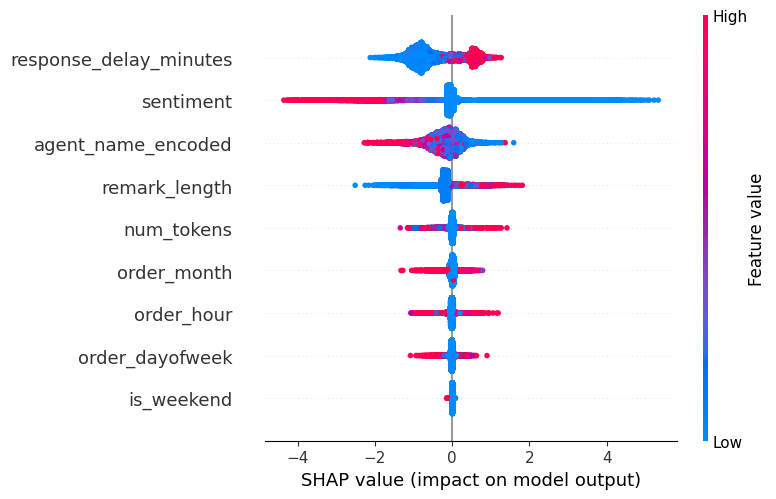

In [63]:
shap.summary_plot(shap_values, X_test)

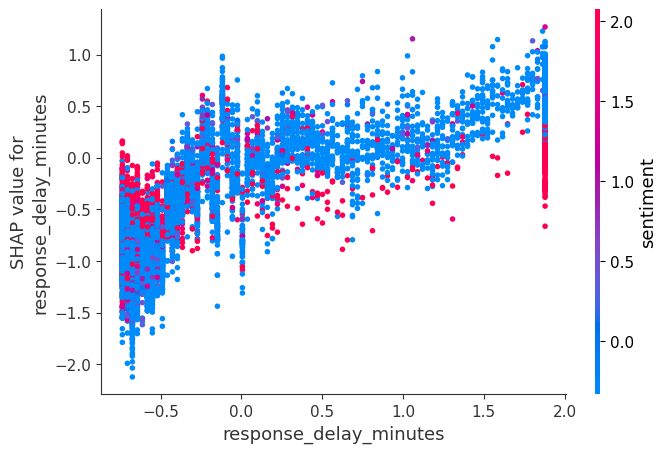

In [64]:
shap.dependence_plot("response_delay_minutes", shap_values, X_test)

In [65]:
joblib.dump(best_xgb, 'xgb.pkl')
joblib.dump(sc, 'scaler.pkl')

feature_list = list(X_train.columns)
with open('feature_list.json', 'w') as f:
    json.dump(feature_list, f)

joblib.dump(agent_freq, 'agent_freq.pkl')

['agent_freq.pkl']

In [66]:
dataset.columns

Index(['response_delay_minutes', 'order_dayofweek', 'order_month',
       'order_hour', 'agent_name_encoded', 'is_weekend', 'remark_length',
       'num_tokens', 'sentiment', 'csat_score'],
      dtype='object')

In [ ]:
min_encoded = min(agent_freq.values())

min_agents = [agent for agent, freq in agent_freq.items() if freq == min_encoded]

print("Minimum agent_name_encoded value:", min_encoded)
print("Agent(s) with this frequency:", min_agents)


Minimum agent_name_encoded value: 20
Agent(s) with this frequency: ['Joel Garcia', 'John Perry', 'Christopher Roberson', 'Richard Gordon', 'Nicole Simpson DVM', 'Virginia Collins', 'Terri Lopez', 'Samantha Harmon', 'James Blevins', 'Bradley Lyons', 'Karen Martin', 'Tina Ramirez', 'Sarah Bennett', 'Karen Alvarado', 'Melissa Spence', 'Summer Mitchell', 'Rachel Smith MD', 'John Torres', 'Robin Spencer', 'Michael Jenkins', 'Willie Flores', 'David Martin', 'William Mueller', 'Shane Payne', 'Mark Lucas', 'Jackson Brown', 'Alexis Murray', 'Matthew Ross', 'Stephanie Hammond', 'Amy Bell']
